In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib

In [3]:
card_data = pd.read_csv('creditcard.csv')

In [4]:
card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
mean_value = card_data.groupby('Class').mean()
mean_value

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


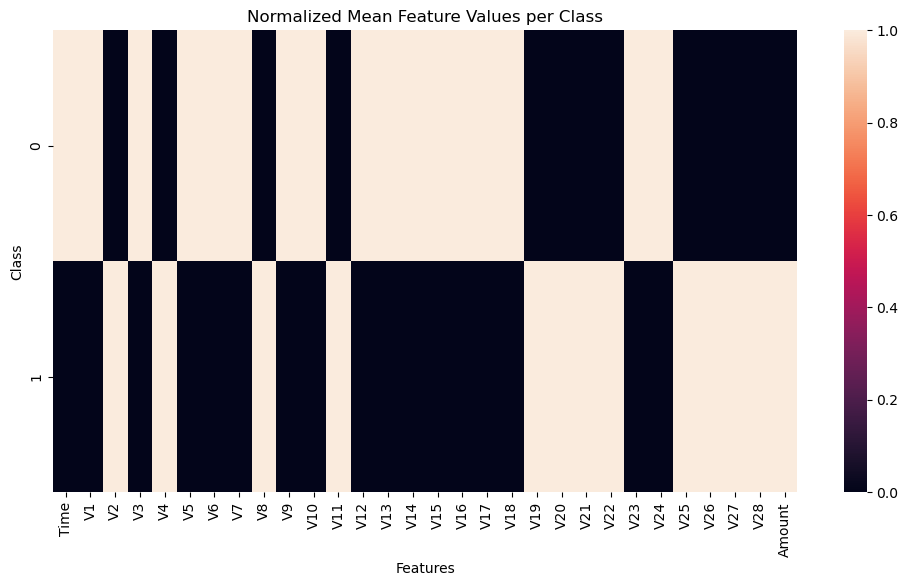

In [7]:

mean_values = card_data.groupby('Class').mean()
normalized = (mean_values - mean_values.min()) / (mean_values.max() - mean_values.min())
plt.figure(figsize=(12, 6))
sns.heatmap(normalized)
plt.title("Normalized Mean Feature Values per Class")
plt.xlabel("Features")
plt.ylabel("Class")
plt.show()


In [8]:
normal = card_data[card_data['Class'] == 0]
fraud = card_data[card_data['Class'] == 1]

In [9]:
normal.shape

(284315, 31)

In [10]:
fraud.shape


(492, 31)

In [11]:
new_normal_sample = normal.sample(n=492)

In [12]:
new_cridat_data = pd.concat([new_normal_sample, fraud])

In [13]:
new_cridat_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
181421,124966.0,2.278486,-0.625642,-1.775772,-1.090355,0.135643,-0.533868,-0.209593,-0.324378,-0.559458,...,-0.017799,-0.011010,0.123804,0.062959,0.132211,-0.271752,-0.041283,-0.061525,15.00,0
167580,118772.0,-0.844571,0.710329,0.347978,-1.224369,1.580164,-0.056969,1.040907,-0.097027,-0.712742,...,0.319931,0.928032,-0.888407,-1.260589,1.301935,1.182893,-0.228827,0.038404,2.92,0
15900,27340.0,1.228394,0.243785,0.171467,0.507540,-0.201555,-0.568145,-0.053004,-0.006915,-0.126136,...,-0.261283,-0.823707,0.078169,-0.056495,0.211420,0.098950,-0.031519,0.016875,5.99,0
272830,165286.0,2.064079,0.713077,-3.138771,0.604254,1.357638,-1.332843,0.781312,-0.390327,-0.366248,...,-0.005686,0.195377,-0.059836,0.617705,0.394404,0.655933,-0.079835,-0.020756,0.76,0
115945,74084.0,1.335013,-1.388218,0.715929,-1.514463,-1.596372,0.213664,-1.461377,0.226319,-1.697831,...,-0.160688,-0.221724,0.068529,-0.353577,0.055105,-0.266771,0.054498,0.021967,59.70,0


In [14]:
new_cridat_data['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [15]:
new_mean = new_cridat_data.groupby('Class').mean()
new_mean

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,92908.508130,0.074051,0.057946,0.076936,-0.054972,-0.049176,0.095844,-0.075655,0.041801,-0.057875,...,0.003157,-0.015371,-0.000460,0.022822,0.060958,-0.026999,-0.004268,-0.014828,0.001953,78.049614
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


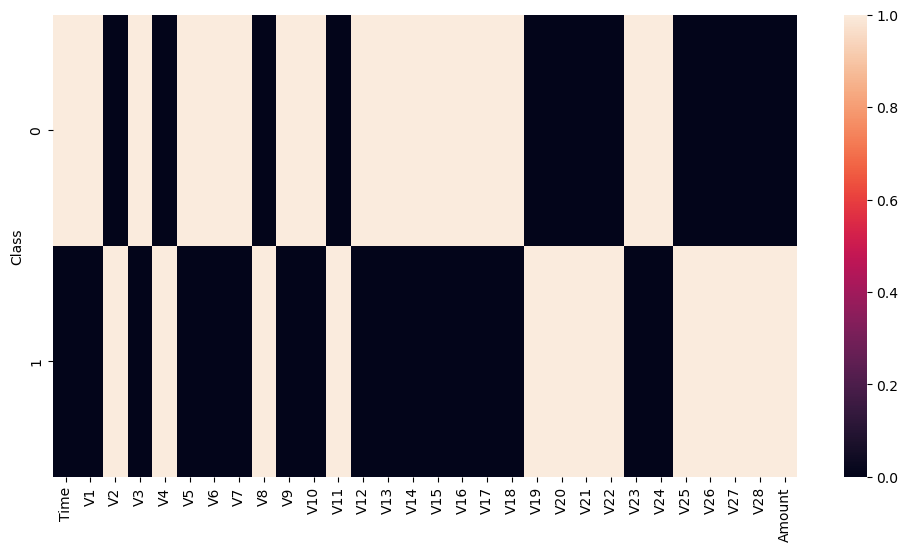

In [16]:
norm = (new_mean - new_mean.min()) / (new_mean.max() - new_mean.min())
plt.figure(figsize=(12, 6))
sns.heatmap(norm)
plt.show()

In [17]:
x = new_cridat_data.drop('Class', axis=1)

In [19]:
x.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
181421,124966.0,2.278486,-0.625642,-1.775772,-1.090355,0.135643,-0.533868,-0.209593,-0.324378,-0.559458,...,0.056553,-0.017799,-0.011010,0.123804,0.062959,0.132211,-0.271752,-0.041283,-0.061525,15.00
167580,118772.0,-0.844571,0.710329,0.347978,-1.224369,1.580164,-0.056969,1.040907,-0.097027,-0.712742,...,-0.002587,0.319931,0.928032,-0.888407,-1.260589,1.301935,1.182893,-0.228827,0.038404,2.92
15900,27340.0,1.228394,0.243785,0.171467,0.507540,-0.201555,-0.568145,-0.053004,-0.006915,-0.126136,...,-0.083583,-0.261283,-0.823707,0.078169,-0.056495,0.211420,0.098950,-0.031519,0.016875,5.99
272830,165286.0,2.064079,0.713077,-3.138771,0.604254,1.357638,-1.332843,0.781312,-0.390327,-0.366248,...,-0.062888,-0.005686,0.195377,-0.059836,0.617705,0.394404,0.655933,-0.079835,-0.020756,0.76
115945,74084.0,1.335013,-1.388218,0.715929,-1.514463,-1.596372,0.213664,-1.461377,0.226319,-1.697831,...,-0.281713,-0.160688,-0.221724,0.068529,-0.353577,0.055105,-0.266771,0.054498,0.021967,59.70


In [22]:
y = new_cridat_data[['Class']]
y.head()

,Class
181421,0
167580,0
15900,0
272830,0
115945,0


In [23]:
y.value_counts()

Class
0        492
1        492
Name: count, dtype: int64

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=.2)

In [25]:
model = LogisticRegression()

In [26]:
model.fit(x_train, y_train)

/home/ahmed/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ahmed/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
#accuracy on training data
y_train_predict = model.predict(x_train)
accuracy_train = accuracy_score(y_train, y_train_predict)
print(accuracy_train)

0.9491740787801779


In [29]:
#accuracy on test_data
y_test_predict = model.predict(x_test)
accuracy_test = accuracy_score(y_test, y_test_predict)
print(accuracy_test)

0.934010152284264


In [31]:
joblib.dump(model, 'model.pkl')

['model.pkl']